# 04.파이썬라이브러리-Seaborn

## Seaborn 설치하기

In [ ]:
!pip install seaborn    # 최초 한번만 실행하기

### Seaborn 버전 확인 

In [ ]:
import seaborn 

seaborn.__version__

## Seaborn 사용 예:

### 1. Matplotlib과 기본 그래프 비교

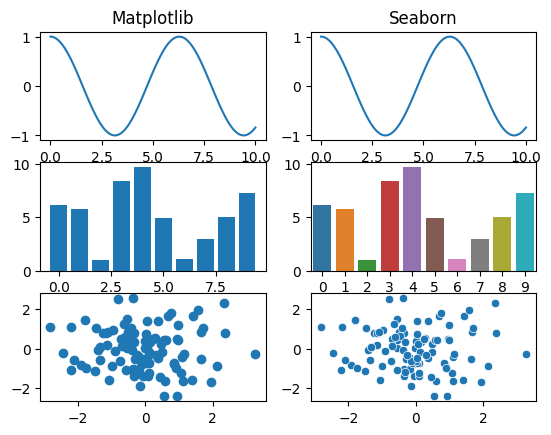

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import warnings
# warnings.filterwarnings(action='ignore')


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = (6, 4)
plt.style.use('default')

# 선 그래프
X = np.linspace(0, 10, 100)      # 0~10사이의 선형 분포 100개 
Y = np.cos(X)                    # X의 코사인 값
plt.subplot(321)
plt.plot(X, Y)
plt.title('Matplotlib')
plt.subplot(322)
sns.lineplot(X, Y)
plt.title('Seaborn')

# 막대 그래프
X = np.arange(10)                # 0~9사이의 연속값
Y = np.random.uniform(1,10,10)   # 균일분포값 생성
plt.subplot(323)
plt.bar(X, Y)
plt.subplot(324)
sns.barplot(X, Y)

# 점 그래프
X = np.random.randn(100)         # 정규 분포를 가지는 데이터
Y = np.random.randn(100)         # 정규 분포를 가지는 데이터
plt.subplot(325)
plt.scatter(X, Y)
plt.subplot(326)
sns.scatterplot(X, Y)

plt.show()

### 2. Seaborn 내장 Dataset 사용해서 그래프 그리기
- csv파일: https://github.com/mwaskom/seaborn-data

#### - Seaborn 데이터셋 목록

In [96]:
# Seaborn 데이터셋 목록
sns.get_dataset_names()  # 19개

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'exercise',
 'flights',
 'fmri',
 'gammas',
 'geyser',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'taxis',
 'tips',
 'titanic']

#### - 데이터셋 불러오기

In [97]:
# 데이터셋 불러오기
sns.load_dataset('tips')
sns.load_dataset('tips').head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#### - 변수 사이의  관계 그래프로 나타내기 : pairplot

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


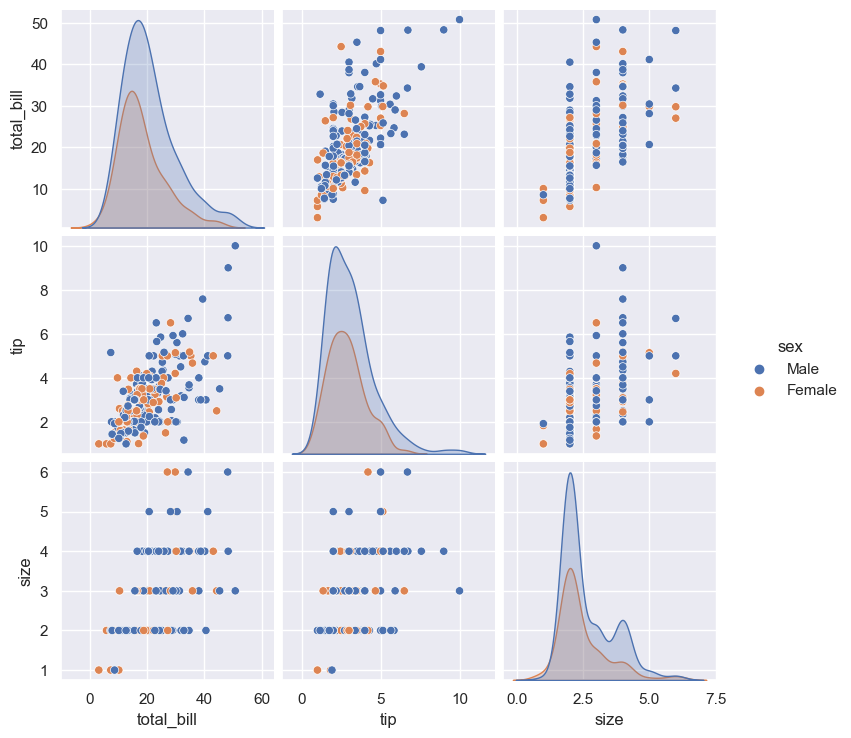

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns


tips = sns.load_dataset('tips')  # 식당 손님들이 식사하고 지불한 팁 Dataset
tips.info()
tips

sns.set_style("darkgrid")
sns.pairplot(tips, hue="sex") # 두 가지 변수 조합을 한 번에 (histogram+scatter)확인
# sns.pairplot(tips, hue="sex", height=2, aspect=3/3)

## 1. Seaborn 기본 설정

### 한글, 폰트크기 설정

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.size'] = 15
# plt.rcParams['axes.unicode_minus'] = False
# plt.rc("font", family = "Malgun Gothic")

sns.set(font="Malgun Gothic", rc={"axes.unicode_minus":False}, style='darkgrid')

sns.set(font_scale=0.7)  # 폰트 크기

### 그래프 크기 변경
1. rcParams함수 사용
2. matplotlib.pyplot.figure()함수 사용
3. matplotlib.pyplot.gcf()함수 사용
4. seaborn.set()함수 사용
5. height 및 aspect 매개변수 사용

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame({"Day 1": [7,1,5,6,3,10,5,8],
                 "Day 2" : [1,2,8,4,3,9,5,2]})

<AxesSubplot:>

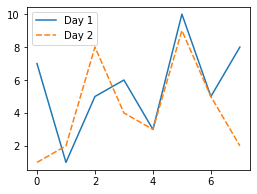

In [4]:
# 1.rcParams함수 사용
plt.rcParams['figure.figsize']=(4, 3)
sns.lineplot(data=df)

<AxesSubplot:>

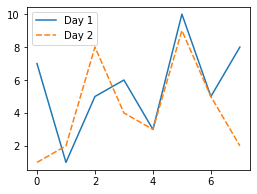

In [5]:
# 2.matplotlib.pyplot.figure()함수 사용
plt.figure(figsize=(4, 3))
sns.lineplot(data=df)

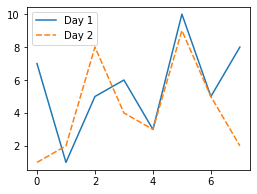

In [6]:
# 3.matplotlib.pyplot.gcf()함수 사용 : Get the current figure
p = sns.lineplot(data=df)
plt.gcf().set_size_inches(4, 3)

<AxesSubplot:>

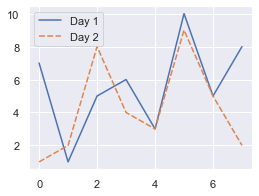

In [7]:
# 4.seaborn.set()함수 사용
sns.set(rc={'figure.figsize':(4, 3)})
sns.lineplot(data=df)

### 그래프 스타일
- sns.set_style("그래프 스타일") : darkgrid(default), whitegrid, dark, white, ticks
- sns.despine() : 축, 테두리 지정 : left, right, top, bottom  # default

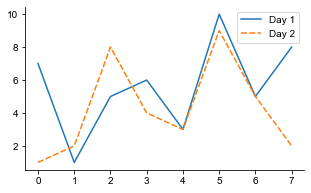

In [5]:
plt.figure(figsize=(5, 3))
sns.lineplot(data=df)  

#그래프를 위에 설정한 후 지정
sns.set_style("white")
sns.despine()

# # 왼쪽, 하단 그리드 표시 안함
# sns.set_style("whitegrid")
# sns.despine(left=True, bottom=True)

### Seaborn Plot 그래프 종류

- https://seaborn.pydata.org/api.html

1. **Multi-plot grid** : 여러 개의 그래프 :FacetGrid, Pairgrid
2. **Relation Plot** : 연속데이터, 관련성 : relplot, scatterplot, lineplot
3. **Distribution Plot** :  데이터 분포 : displot, histplot, kdeplot, ecdfplot, rugplot, distplot
4. **Categorical Plot** : 카테고리 데이터, 변화 : catplot, stripplot, swarmplot, boxplot, violinplot, boxenplot, pointplot, barplot, countplot  
5. **Regression Plot** : 데이터 분포, 회귀선 : lmplot, regplot, residplot
6. **Matrix Plot** : 여러 가지 변수 비교 : heatmap, clustermap

### Seaborn Plotting 방법

- **figure-level** : 
seaborn 의 figure를 만들어 plotting함, facetgrid를 통해 레이아웃을 변경
> g = sns.FacetGrid(tips, col="time", hue='sex', size=3)
> g.map(sns.scatterplot, "total_bill", "tip")
- **axes-level**   : axes 수준에 plotting함. 
plt.figure() 와 같은 메소드로 레이아웃을 변경
> plt.figure(figsize=(6, 3)) <br>
> sns.scatterplot(data=tips, x="total_bill", y="tip")

### Seaborn Class 구조

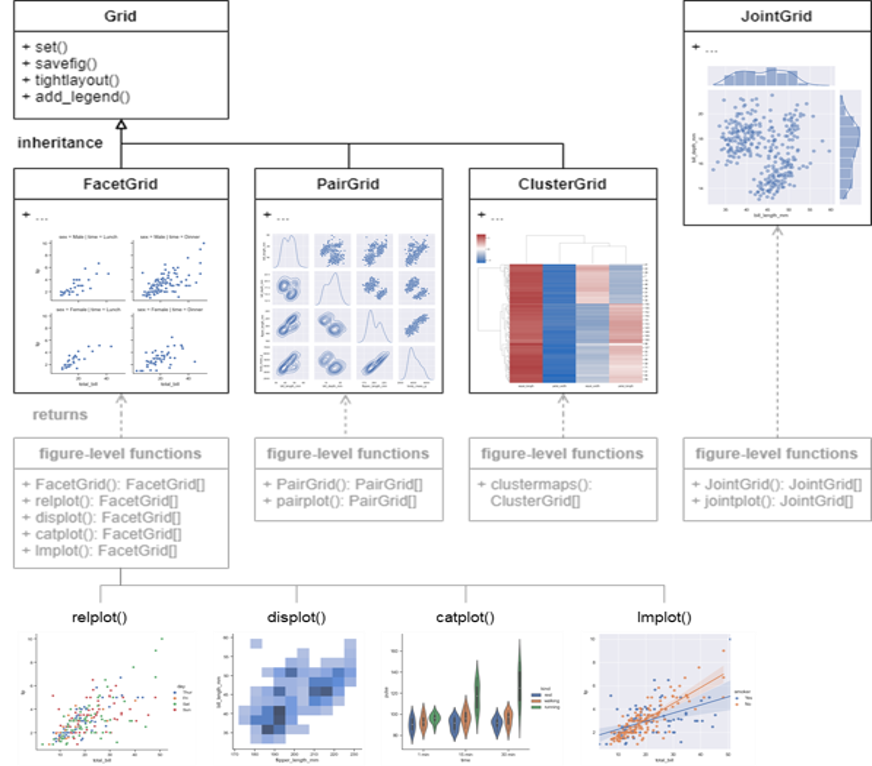

In [175]:
from IPython.display import Image
Image(filename='image\seaborn_class_structure.png')  # 로컬 파일

-------

## Seaborn Plot 그래프

### # Multi-plot grid : 여러 개의 그래프
코드 한 줄로 다양한 그래프를 표시가능

- **facetGrid(패싯그리드)** <br>
조건에 따라 그래프를 각각 확인하고 싶을 때 사용
다양한 범주형 값을 가지는 데이터를 시각화 방법, 여러 개의 서브 플롯 제작, <br>
각 서브 플롯에 적용할 그래프 종류를 map()메서드를 이용하여 그리드 객체에 전달

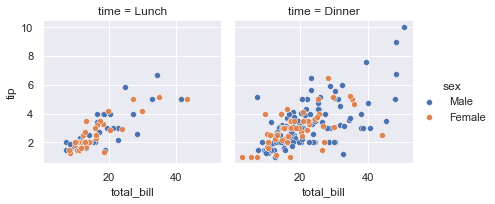

In [15]:
tips = sns.load_dataset('tips')
tips
g = sns.FacetGrid(tips, col="time", hue='sex')
g.map(sns.scatterplot, "total_bill", "tip")
g.add_legend()
g.savefig('graph/sns_scatterplot.png')

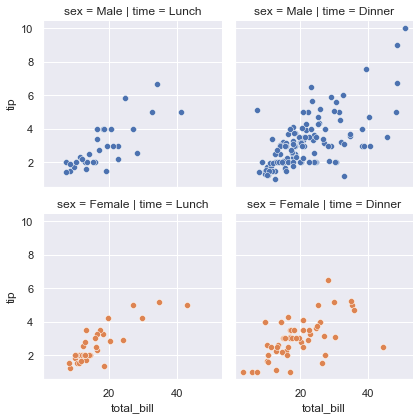

In [17]:
# map & map_dataframe --> 둘 다 동일한 방법
g = sns.FacetGrid(tips, col="time", row="sex", hue='sex')
g.map(sns.scatterplot, "total_bill", "tip")
g.map_dataframe(sns.scatterplot, x="total_bill", y="tip")

- **jointplot** : 두 가지 plot을 한 번에 보는 방법(2차원 데이터), 일변량, 이변량 그래프 표현, kind를 통해 plot 종류를 변경할 수 있음, DataFrame에만 사용할 수 있다
- **통계 용어** 정리
-- 단순(simple) : 독립변수(X) 1
-- 다중(multi) : 독립변수(X) 2이상
-- 일변랑(univariate)   : 종속변수(Y) 1개, 단변량, (T-test, ANOVA, 회귀분석)
-- 이변량(bivariate)    : 종속변수(Y) 2개 (상관분석)
-- 다변량(multivariate) : 종속변수(Y) 2개 이상 (요인분석, 군집분석, 정준상관분석, 다차원척도법 등)

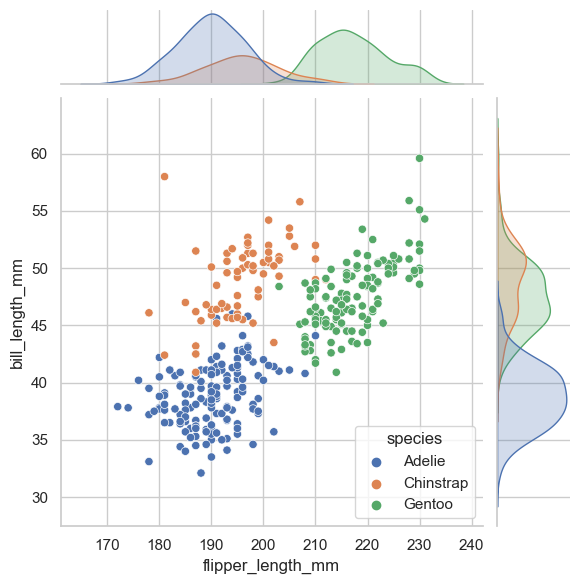

In [171]:
penguins = sns.load_dataset("penguins")

sns.jointplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", 
              hue="species", kind='scatter')

- **Pairplot** :  두 가지 변수 조합을 한 번에 확인 <br>
데이터셋을 통째로 넣으면 숫자형 특성에 대하여 각각에 대한 히스토그램과 두 변수 사이의 scatter plot을 그린다

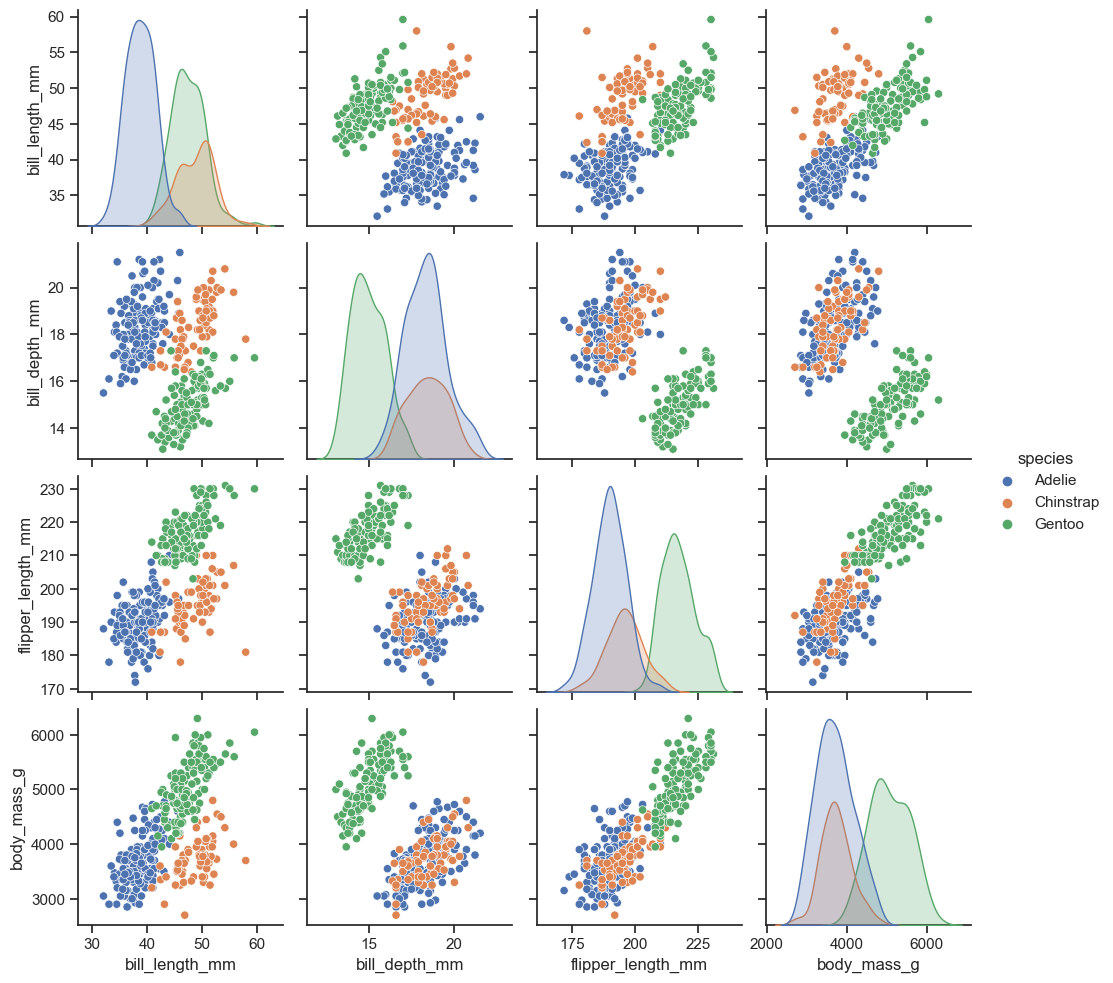

In [286]:
sns.pairplot(data=penguins, hue="species")

-------

### # Relation Plot : 연속데이터, 관련성
- seaborn.**relplot**(*, x=None, y=None, hue=None, size=None, style=None, data=None, row=None, col=None, col_wrap=None, row_order=None, col_order=None, palette=None, hue_order=None, hue_norm=None, sizes=None, size_order=None, size_norm=None, markers=None, dashes=None, style_order=None, legend='auto', kind='scatter', height=5, aspect=1, facet_kws=None, units=None, **kwargs)

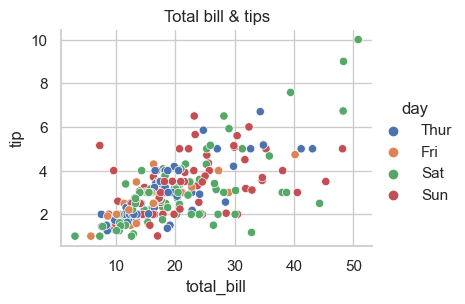

In [150]:
tips = sns.load_dataset("tips")

# plt.figure(figsize=(6, 3)) # 그래프 크기 변경이 안됨(-->axes level)
#  height=3, aspect=4/3 (width = heigh x aspect)
sns.relplot(data=tips, x="total_bill", y="tip", hue="day", height=3, aspect=4/3)
plt.title('Total bill & tips')
plt.show()

- seaborn.**scatterplot**(*, x=None, y=None, hue=None, style=None, size=None, data=None, palette=None, hue_order=None, hue_norm=None, sizes=None, size_order=None, size_norm=None, markers=True, style_order=None, x_bins=None, y_bins=None, units=None, estimator=None, ci=95, n_boot=1000, alpha=None, x_jitter=None, y_jitter=None, legend='auto', ax=None, **kwargs)

<AxesSubplot:xlabel='total_bill', ylabel='tip'>

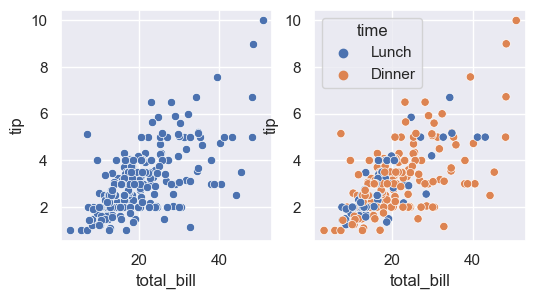

In [82]:
plt.figure(figsize=(6, 3))
plt.subplot(1,2,1)
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.subplot(1,2,2)
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time") # hue(색상)

- seaborn.**lineplot**(*, x=None, y=None, hue=None, size=None, style=None, data=None, palette=None, hue_order=None, hue_norm=None, sizes=None, size_order=None, size_norm=None, dashes=True, markers=None, style_order=None, units=None, estimator='mean', ci=95, n_boot=1000, seed=None, sort=True, err_style='band', err_kws=None, legend='auto', ax=None, **kwargs)

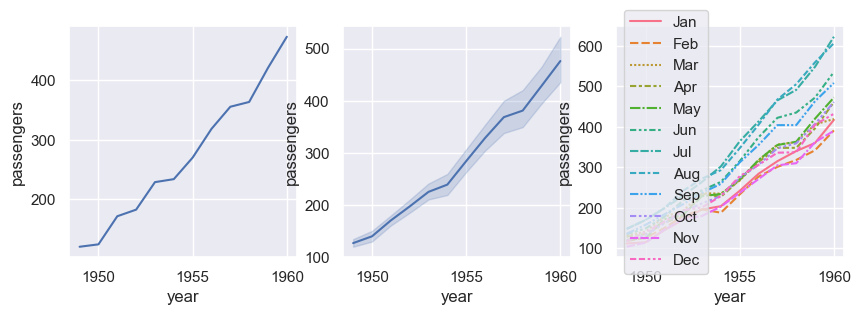

In [79]:
flights = sns.load_dataset("flights")
flights
may_flights = flights.query("month == 'May'") # 6월 데이터
may_flights

plt.figure(figsize=(10, 3))
# 6월:년도별 승객수
plt.subplot(1,3,1)
sns.lineplot(data=may_flights, x="year", y="passengers")  
# 전체:년도별 승객수
plt.subplot(1,3,2)
sns.lineplot(data=flights, x="year", y="passengers") # 전체 추세(분포)와 평균선 표시
# 전체:년도별 월별 승객수
plt.subplot(1,3,3)
sns.lineplot(data=flights, x="year", y="passengers", hue="month", style="month")
plt.legend(loc='center left')
plt.show()

---------

### # Distribution Plot : 데이터 분포를 시각화하는데 도움
이 그래프를 사용하여 데이터의 평균(mean), 중위수(median), 범위(range), 분산(variance), 편차(deviation) 등을 이해할 수 있음

- **displot**
> - histplot() (with **kind="hist"**; the default)
> - kdeplot()  (with **kind="kde"**) 가우시안 커널 밀도 추정
> - ecdfplot() (with **kind="ecdf"**; univariate-only 경험적 누적분포 함수, empirical cumulative distribution functions (ECDFs))

> seaborn.**displot**(data=None, *, x=None, y=None, hue=None, row=None, col=None, weights=None, kind='hist', rug=False, rug_kws=None, log_scale=None, legend=True, palette=None, hue_order=None, hue_norm=None, color=None, col_wrap=None, row_order=None, col_order=None, height=5, aspect=1, facet_kws=None, **kwargs)

- 펭귄데이터: bill_length_mm : 부리 길이

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')
species: ['Adelie' 'Chinstrap' 'Gentoo'] 
island : ['Torgersen' 'Biscoe' 'Dream'] 
sex    : ['Male' 'Female' nan] 


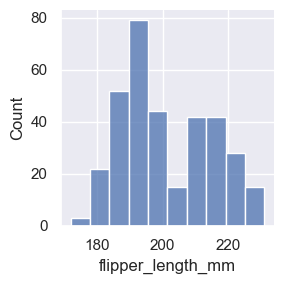

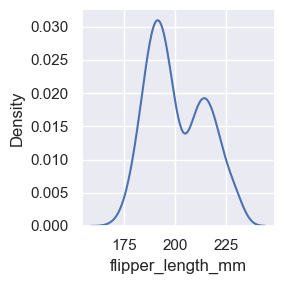

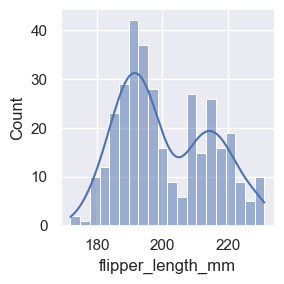

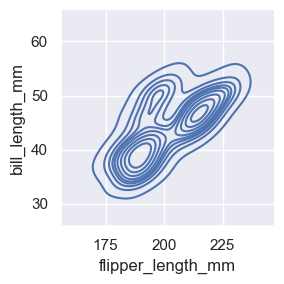

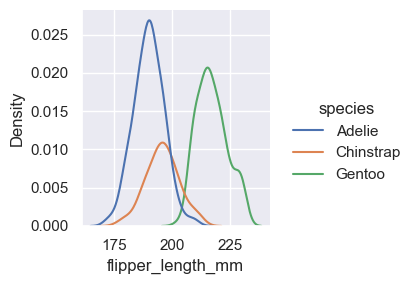

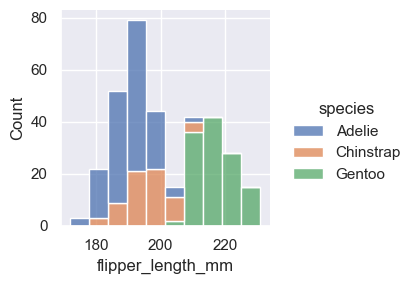

In [208]:
penguins = sns.load_dataset("penguins")
penguins.head()
print(penguins.columns)
print(f'species: {penguins.species.unique()} ')
print(f'island : {penguins.island.unique()} ')
print(f'sex    : {penguins.sex.unique()} ')

sns.displot(data=penguins, x="flipper_length_mm", height=3)
sns.displot(data=penguins, x="flipper_length_mm", kind="kde", height=3) # kernel density estimates (KDEs)
sns.displot(data=penguins, x="flipper_length_mm", kde=True, bins=20, height=3)

sns.displot(data=penguins, x="flipper_length_mm", y="bill_length_mm", kind="kde", height=3)
sns.displot(data=penguins, x="flipper_length_mm", hue="species", kind="kde", height=3)
sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack", height=3)


- **histplot** : 변수에 대한 히스토그램을 표시함, 절대량 표시
> seaborn.**histplot**(data=None, *, x=None, y=None, hue=None, weights=None, stat='count', bins='auto', binwidth=None, binrange=None, discrete=None, cumulative=False, common_bins=True, common_norm=True, multiple='layer', element='bars', fill=True, shrink=1, kde=False, kde_kws=None, line_kws=None, thresh=0, pthresh=None, pmax=None, cbar=False, cbar_ax=None, cbar_kws=None, palette=None, hue_order=None, hue_norm=None, color=None, log_scale=None, legend=True, ax=None, **kwargs)

<AxesSubplot:xlabel='total_bill', ylabel='Count'>

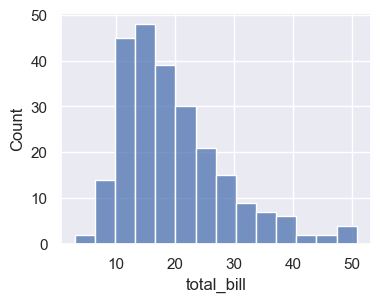

In [264]:
plt.figure(figsize=(4, 3))
sns.histplot(data=tips, x="total_bill")

<AxesSubplot:xlabel='flipper_length_mm', ylabel='Count'>

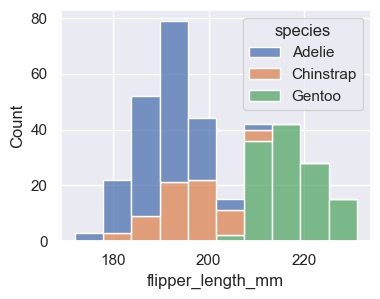

In [265]:
plt.figure(figsize=(4, 3))
sns.histplot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack")

- **kdeplot** : kernel density estimates (KDEs)<br>
커널 밀도(kernel density)는 커널이라는 함수를 겹치는 방법으로 히스토그램보다 부드러운 형태의 분포 곡선을 보여주는 방법 <br>
가우시안 커널 밀도 추정(Gaussian kernel density estimation), 
결과로 연속된 곡선의 그래프를 얻을 수 있음.
- https://scikit-learn.org/stable/modules/density.html
> seaborn.**kdeplot**(x=None, *, y=None, shade=None, vertical=False, kernel=None, bw=None, gridsize=200, cut=3, clip=None, legend=True, cumulative=False, shade_lowest=None, cbar=False, cbar_ax=None, cbar_kws=None, ax=None, weights=None, hue=None, palette=None, hue_order=None, hue_norm=None, multiple='layer', common_norm=True, common_grid=False, levels=10, thresh=0.05, bw_method='scott', bw_adjust=1, log_scale=None, color=None, fill=None, data=None, data2=None, warn_singular=True, **kwargs)

<AxesSubplot:xlabel='Density', ylabel='flipper_length_mm'>

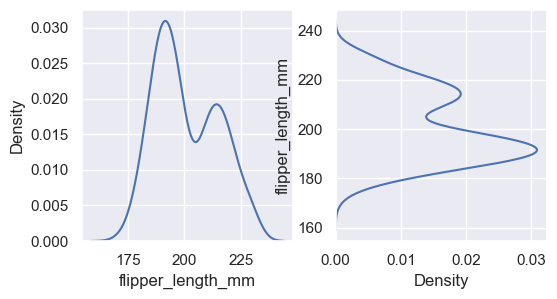

In [241]:
plt.figure(figsize=(6, 3))
plt.subplot(121)
sns.kdeplot(data=penguins, x="flipper_length_mm")
plt.subplot(122)
sns.kdeplot(data=penguins, y="flipper_length_mm")

<AxesSubplot:ylabel='Density'>

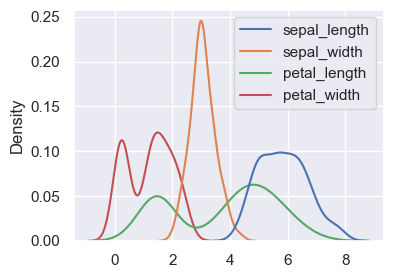

In [243]:
plt.figure(figsize=(4, 3))
iris = sns.load_dataset("iris")
sns.kdeplot(data=iris)

- **ecdfplot** : empirical cumulative distribution functions (ECDFs) 경험적 누적분포를 시각화 해줌, 실제 관측치이의 비율을 시각화 함.
> seaborn.**ecdfplot**(data=None, *, x=None, y=None, hue=None, weights=None, stat='proportion', complementary=False, palette=None, hue_order=None, hue_norm=None, log_scale=None, legend=True, ax=None, **kwargs)

<AxesSubplot:xlabel='flipper_length_mm', ylabel='Proportion'>

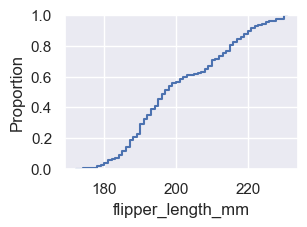

In [244]:
sns.ecdfplot(data=penguins, x="flipper_length_mm")

- **rugplot** : 실수 분포 플롯, 자료의 분포를 묘사하기 위한 것으로 주변 분포도를 표시함.  데이터 위치를 x축 위에 작은선분(rug)으로 나타내어 실제 데이터의 위치를 보여줌. 다른 그림들을 보완하는데 주로 사용됨
> seaborn.**rugplot**(x=None, *, height=0.025, axis=None, ax=None, data=None, y=None, hue=None, palette=None, hue_order=None, hue_norm=None, expand_margins=True, legend=True, a=None, **kwargs)

<AxesSubplot:xlabel='total_bill', ylabel='Density'>

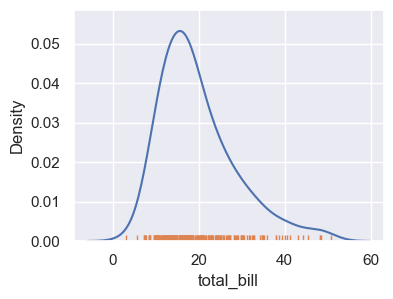

In [246]:
plt.figure(figsize=(4, 3))
sns.kdeplot(data=tips, x="total_bill")
sns.rugplot(data=tips, x="total_bill")

- **distplot** :  기능을 displot, histplot 으로 표현 가능
distplot 명령은 러그와 커널 밀도 표시 기능이 있어서 Matplotlib의 hist 명령보다 많이 사용된

c:\python\python38\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
c:\python\python38\lib\site-packages\seaborn\distributions.py:2103: FutureWarning: The `axis` variable is no longer used and will be removed. Instead, assign variables directly to `x` or `y`.
  warnings.warn(msg, FutureWarning)


<AxesSubplot:>

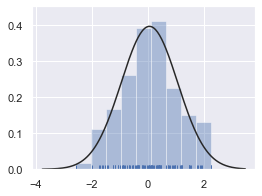

In [22]:
import seaborn as sns, numpy as np
import pandas as pd 
from scipy.stats import norm 

np.random.seed(0)
x = np.random.randn(100)
# x = pd.Series(x, name="x variable")
x = pd.Series(x)
sns.distplot(x, fit=norm, kde=False, rug=True)

--------

### # Regression Plot : 데이터 분포, 회귀선
회귀분석(머신러닝) 결과를 그래프에 표기해줌. 데이터를 있는 그대로 보여주기보다는, 회귀분석(머신러닝) 결과와 함께 보여주는 것이다

- **lmplot** 
regplot과 유사한 선형 회귀 직선을 구하는 기능을 가지고 있음<br>
- anscombe Dataset
> 1973년 통계학자 프란시스 앤스컴이 데이터 분석에 앞서 시각화의 중요성과 특이치 값의 영향을 보여주기 위해 만듦

> seaborn.**lmplot**(*, x=None, y=None, data=None, hue=None, col=None, row=None, palette=None, col_wrap=None, height=5, aspect=1, markers='o', sharex=None, sharey=None, hue_order=None, col_order=None, row_order=None, legend=True, legend_out=None, x_estimator=None, x_bins=None, x_ci='ci', scatter=True, fit_reg=True, ci=95, n_boot=1000, units=None, seed=None, order=1, **logistic=False**, lowess=False, robust=False, logx=False, x_partial=None, y_partial=None, truncate=True, x_jitter=None, y_jitter=None, scatter_kws=None, line_kws=None, facet_kws=None, size=None)

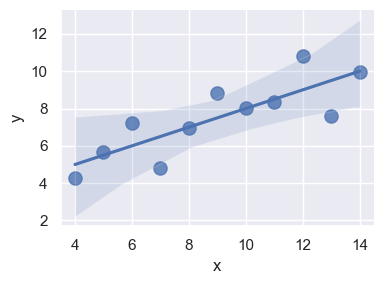

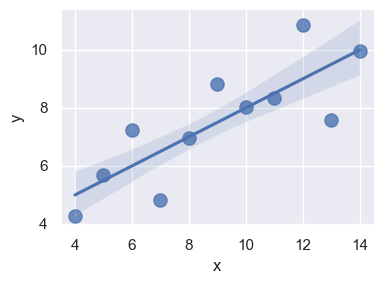

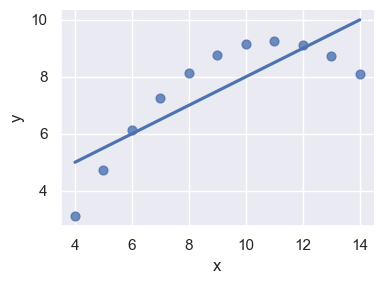

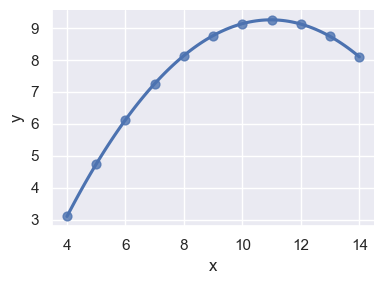

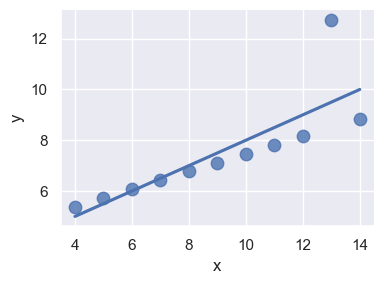

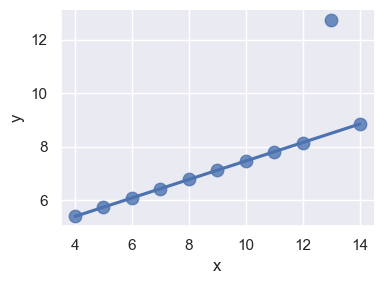

In [231]:
import seaborn as sns

anscombe = sns.load_dataset('anscombe')
anscombe

sns.lmplot(x="x", y='y', data=anscombe.query("dataset=='I'"),
           ci=100, scatter_kws={'s':90}, height=3, aspect=4/3)

sns.lmplot(x="x", y='y', data=anscombe.query("dataset=='I'"),
           ci=80, scatter_kws={'s':90}, height=3, aspect=4/3)

sns.lmplot(x="x", y='y', data=anscombe.query("dataset=='II'"),
           ci=None, scatter_kws={'s':40}, height=3, aspect=4/3)

# 2차 함수 사용(order=2)
sns.lmplot(x="x", y='y', data=anscombe.query("dataset=='II'"),
           order=2, ci=None, scatter_kws={'s':40}, height=3, aspect=4/3)


# 이상치가 존재하는 경우
sns.lmplot(x="x", y='y', data=anscombe.query("dataset=='III'"),
           ci=None, scatter_kws={'s':80}, height=3, aspect=4/3)

# 이상치가 존재하는 경우 --> 해결(robust=True)
sns.lmplot(x="x", y='y', data=anscombe.query("dataset=='III'"),
           robust=True, ci=None, scatter_kws={'s':80}, height=3, aspect=4/3)

- **regplot** 
선형적인 관계가 있는 데이터를 직선을 그어 확인하는 방법

Text(0.5, 1.0, 'Total Bill and Tip')

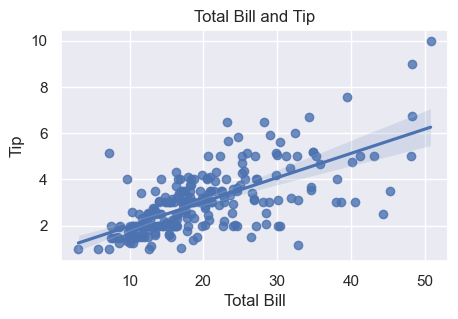

In [223]:
plt.figure(figsize=(5, 3))
ax = sns.regplot(data=tips, x='total_bill', y='tip')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Tip')
ax.set_title('Total Bill and Tip')

- **residplot**

---------

### # Categorical Plot : 카테고리 데이터, 변화
범주형(categorical) 변수를 이해하는데 도움, 일변량(univariate) 혹은 이변량(bivariate) 분석에 사용됨

- **catplot**   
> seaborn.**catplot**(*, x=None, y=None, hue=None, data=None, row=None, col=None, col_wrap=None, estimator=<function mean at 0x7ff320f315e0>, ci=95, n_boot=1000, units=None, seed=None, order=None, hue_order=None, row_order=None, col_order=None, kind='strip', height=5, aspect=1, orient=None, color=None, palette=None, legend=True, legend_out=True, sharex=True, sharey=True, margin_titles=False, facet_kws=None, **kwargs)

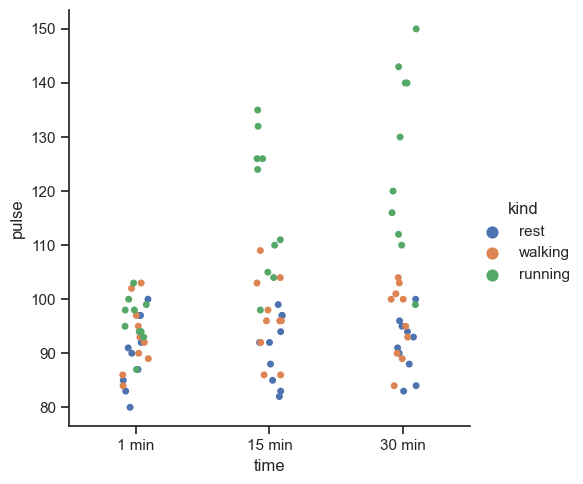

In [274]:
import seaborn as sns
sns.set_theme(style="ticks")
exercise = sns.load_dataset("exercise")
g = sns.catplot(x="time", y="pulse", hue="kind", data=exercise)

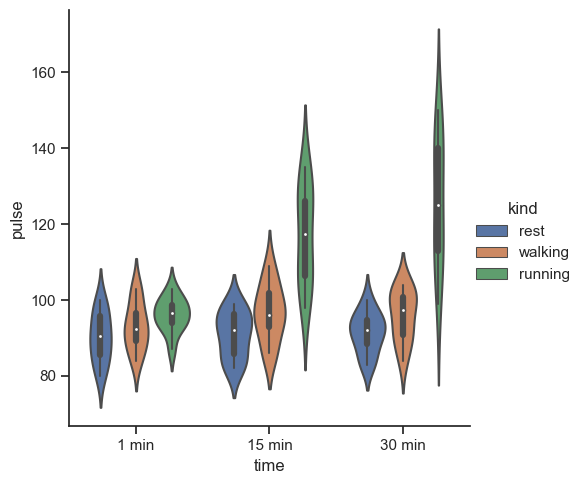

In [275]:
g = sns.catplot(x="time", y="pulse", hue="kind",
               data=exercise, kind="violin")

- **barplot** : 이변량(bivariate) 분석을 위한 plot
X축에는 범주형 변수, Y축에는 연속형 변수를 넣는다.

<AxesSubplot:xlabel='sex', ylabel='tip'>

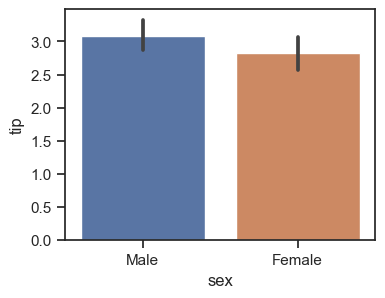

In [277]:
plt.figure(figsize=(4, 3))
sns.barplot(data=tips, x='sex', y='tip')

- **countplot** : 각 카테고리 값별로 데이터가 얼마나 있는지 표시할 수 있다. 범주형 변수의 발생 횟수 나타냄, 일변량(univariate) 분석임

<AxesSubplot:xlabel='sex', ylabel='count'>

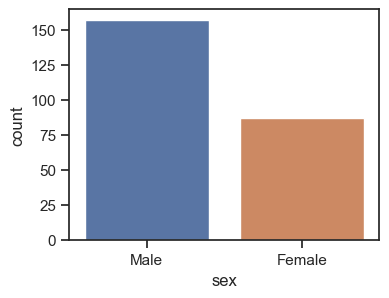

In [278]:
plt.figure(figsize=(4, 3))
sns.countplot(data=tips, x='sex')

- **boxplot** :특이치(outlier)를 발견하기 위한 것으로, 최대(maximum), 최소(minimum), mean(평균), 1 사분위수(first quartile), 3 사분위수(third quartile)를 보기 위한 그래프, <br>
단일 연속형 변수에 대해 수치를 표시하거나 연속형 변수를 기반으로 서로다른 범주형 변수를 분석

<AxesSubplot:xlabel='smoker', ylabel='total_bill'>

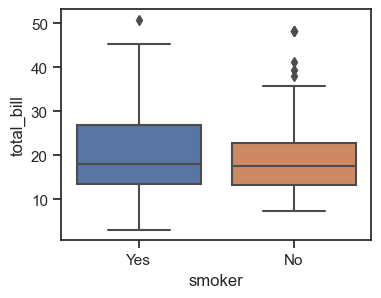

In [279]:
plt.figure(figsize=(4, 3))
sns.boxplot(data=tips, x='smoker', y='total_bill')

- **violinplot** : boxplot의 분포에 대한 보충정보 제공

<AxesSubplot:xlabel='smoker', ylabel='total_bill'>

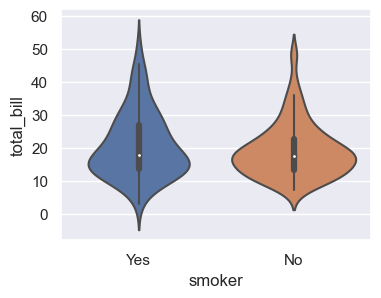

In [271]:
plt.figure(figsize=(4, 3))
sns.violinplot(data=tips, x='smoker', y='total_bill')

- **stripplot** : 연속형 변수와 범주형 변수 사이의 그래프 <br>
산점도로 표시되는데 범주형 변수의 인코딩을 추가로 사용한다.

<AxesSubplot:xlabel='smoker', ylabel='total_bill'>

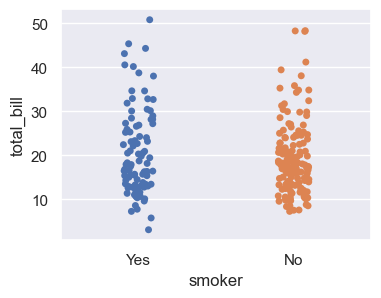

In [272]:
plt.figure(figsize=(4, 3))
sns.stripplot(data=tips, x='smoker', y='total_bill')

- **swarmplot** : stripplot과 violinplot의 조합, 데이터 포인트 수와 함께 각 데이터의 분포도 제공함

<AxesSubplot:xlabel='smoker', ylabel='total_bill'>

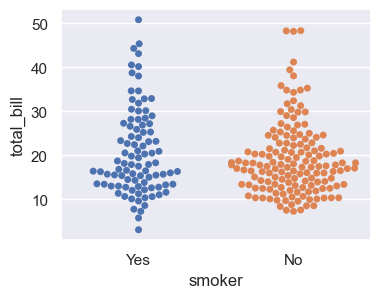

In [273]:
plt.figure(figsize=(4, 3))
sns.swarmplot(data=tips, x='smoker', y='total_bill')

- boxenplot

- pointplot

---------

### # Matrix Plot : 여러 가지 변수 비교
시각화를 위해 2차원 행렬 데이터를 사용하는 특별한 유형의 plot

- **heatmap** : 데이터 간의 수치에 따라 색상을 입힘으로써 직관적인 통찰을 얻을 수 있음.
> seaborn.**heatmap**(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)

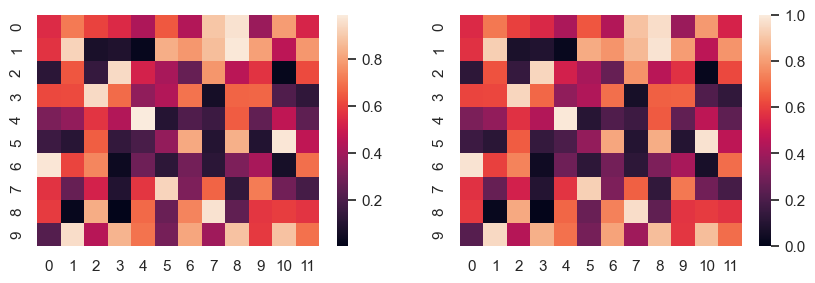

In [259]:
import numpy as np; np.random.seed(0)
import seaborn as sns

uniform_data = np.random.rand(10, 12)  # 0과 1사이의 균일 분포 난수
normal_data  = np.random.randn(10, 12) # 기댓값이 0이고 표준편차가 1인 표준 정규 분포
# print(f'uniform_data : {uniform_data}')
# print(f'normal_data  : {normal_data}')

plt.figure(figsize=(10, 3))

plt.subplot(121)
ax = sns.heatmap(uniform_data)

plt.subplot(122)
ax = sns.heatmap(uniform_data, vmin=0, vmax=1)

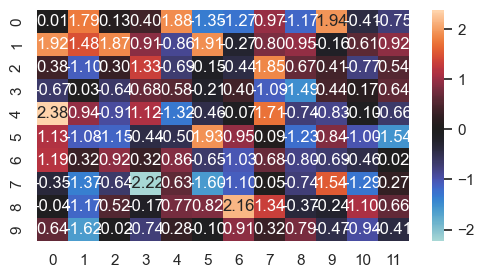

In [262]:
plt.figure(figsize=(6, 3))
ax = sns.heatmap(normal_data, center=0, annot=True, fmt=".2f")

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


<AxesSubplot:>

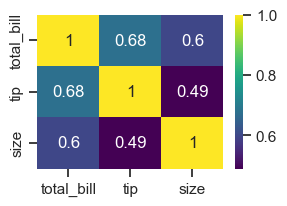

In [282]:
# 변수간 상관계수를 시각적으로 확인 가능
print(tips.corr())
sns.heatmap(tips.corr(), annot=True, cmap = 'viridis')

<AxesSubplot:>

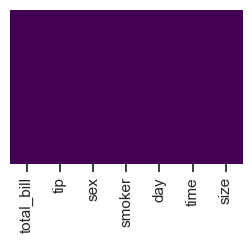

In [283]:
# 결측치(missing value)를 그래프로 확인할 수 있음
sns.heatmap(tips.isnull(),yticklabels=False,cbar=False,cmap='viridis')

- **clustermap** : hierarchically-clustered heatmap
행렬 데이터를 가지고 있고, 유사성에 따라 몇몇 특징들을 그룹화할 필요가 있을 때 사용함
> seaborn.**clustermap**(data, *, pivot_kws=None, method='average', metric='euclidean', z_score=None, standard_scale=None, figsize=(10, 10), cbar_kws=None, row_cluster=True, col_cluster=True, row_linkage=None, col_linkage=None, row_colors=None, col_colors=None, mask=None, dendrogram_ratio=0.2, colors_ratio=0.03, cbar_pos=(0.02, 0.8, 0.05, 0.18), tree_kws=None, **kwargs)

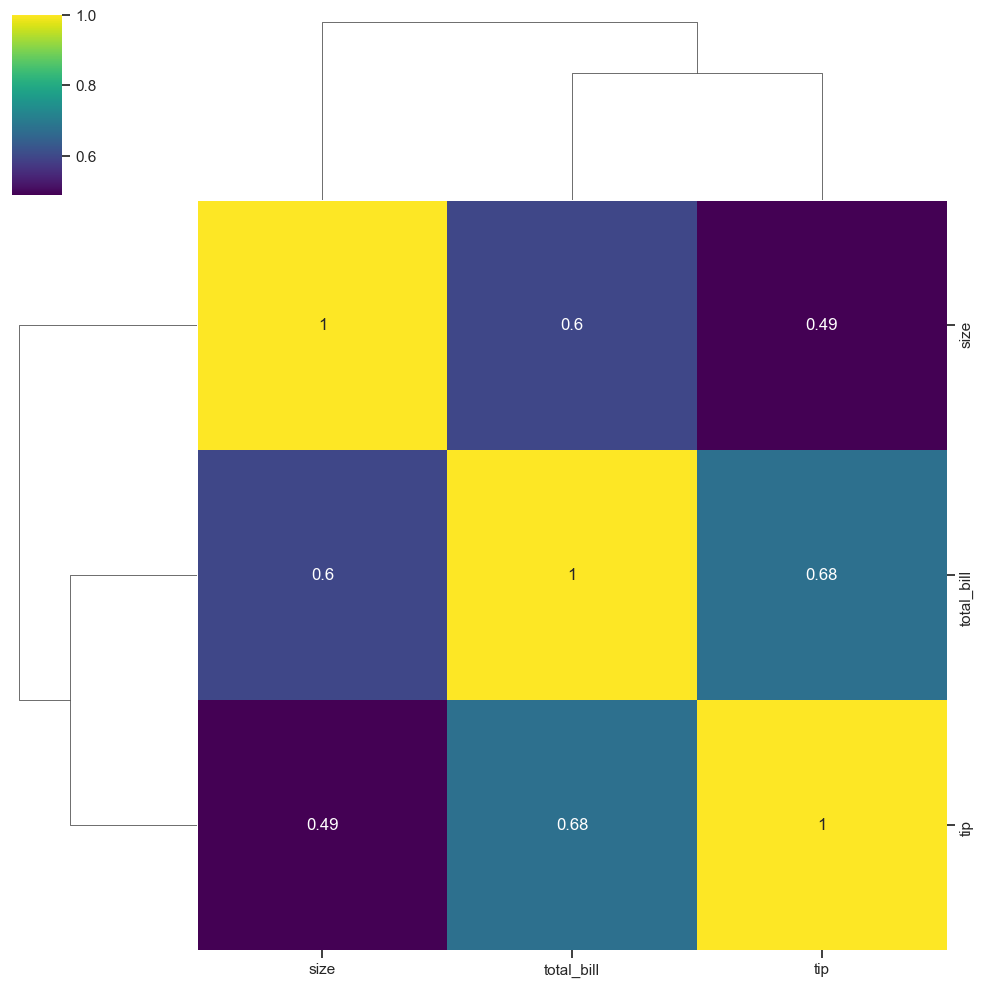

In [284]:
sns.clustermap(tips.corr(), annot=True, cmap = 'viridis')

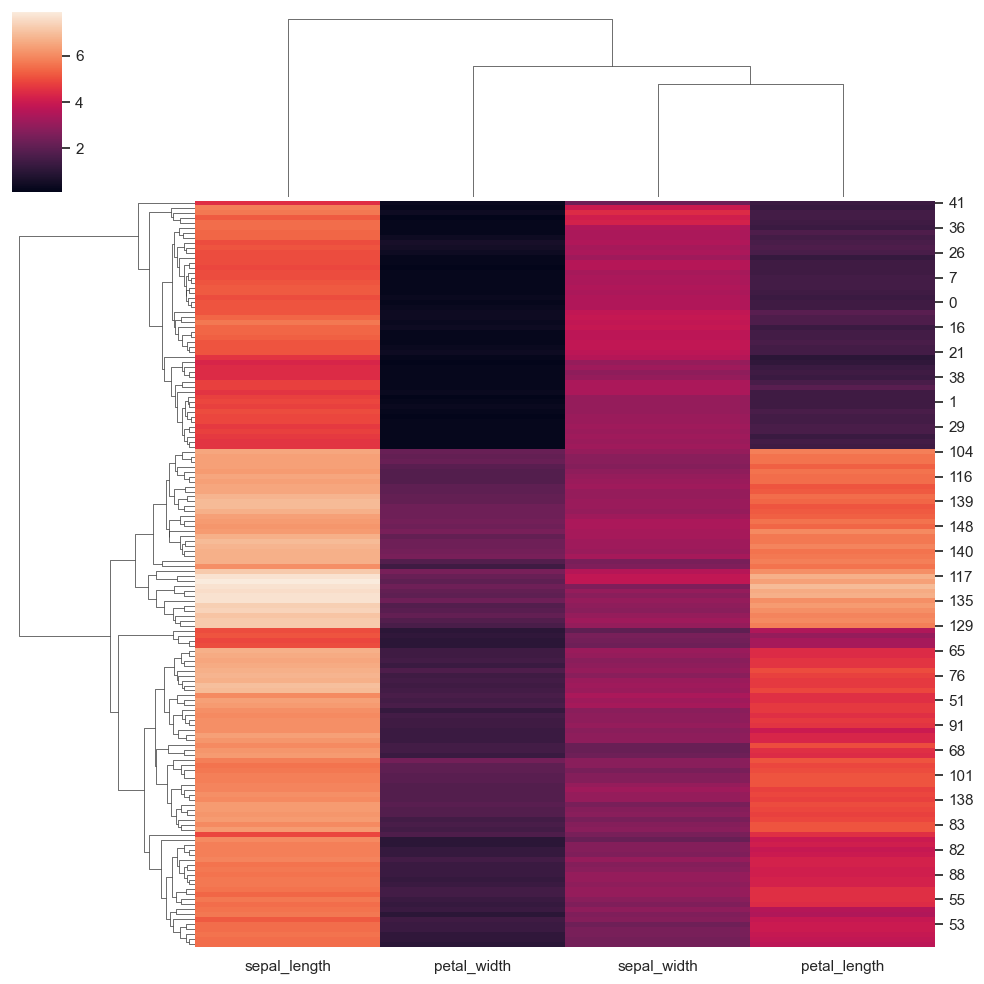

In [263]:
import seaborn as sns

sns.set_theme(color_codes=True)
iris = sns.load_dataset("iris")

species = iris.pop("species")
g = sns.clustermap(iris)

---------

끝